# Lessons learned

1. Even if ids are different but datapoints match, they are duplicates
2. Try adjusting the threshold to sacrifice recall and gain precision

# Logistic model

## Data retrieval 

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:
loan_df = pd.read_csv(r'loan_data2.csv')
loan_df.drop('Loan_ID', axis=1, inplace=True)

## Data cleaning

### Duplicated entries

In [3]:
loan_df.duplicated().sum()

np.int64(8822)

In [4]:
loan_df.drop_duplicates(inplace=True)

### Inconsistent entries

In [5]:
# Data points with missing values in Income and Loan amount
i_entries = loan_df[loan_df['ApplicantIncome'].isna() & loan_df['LoanAmount'].isna()]
indices = i_entries.index

# Remove each of such entry from the df 
for i in indices:
    loan_df.drop(i, inplace=True)

### Missing values 

#### Checklist

In [6]:
loan_df.shape

(1173, 5)

In [7]:
loan_df.isna().sum()

Gender               0
Married              0
ApplicantIncome    256
LoanAmount         341
Loan_Status          0
dtype: int64

In [8]:
loan_df.describe()

,ApplicantIncome,LoanAmount
count,917.000000,832.000000
mean,5355.683751,144.104567
std,5896.050000,83.444051
min,150.000000,9.000000
25%,2882.000000,99.000000
50%,3846.000000,126.500000
75%,5800.000000,166.250000
max,81000.000000,650.000000


#### ApplicantIncome

In [9]:
# aggregate fn. allows you perform a list of functions on a df
# Obtain avg. Income using incomes of ppl with similar loan amounts
app_incomes = loan_df.groupby('LoanAmount')['ApplicantIncome'].aggregate(['count','mean'])
app_incomes

,count,mean
LoanAmount,,
9.0,1,2378.0
17.0,1,1299.0
25.0,2,3539.5
26.0,1,5468.0
30.0,2,2387.5
...,...,...
496.0,1,12000.0
500.0,1,18333.0
570.0,1,19730.0


In [10]:
# Get the indices of missing app. incomes
missing_incomes = loan_df[loan_df['ApplicantIncome'].isna()].index 

# Fill all missing income values with befitting avg.
for missing_income in missing_incomes:
    # Get its loan amount
    loan_amount = loan_df.loc[missing_income, 'LoanAmount']
    income = 0
    # Check for the avg. value to fill income with
    for entry in app_incomes.index:
        if entry == loan_amount:
            income = app_incomes['mean'][entry]
            break
    # Replace the missing entry
    loan_df.loc[missing_income, 'ApplicantIncome'] = round(income, 2)

# Display infected rows to verify correctness of updates
loan_df.loc[missing_incomes,]

,Gender,Married,ApplicantIncome,LoanAmount,Loan_Status
30,Male,Yes,4182.67,132.0,N
54,Male,Yes,6527.00,150.0,N
62,Female,Yes,4982.60,130.0,Y
83,Male,Yes,4784.09,128.0,Y
101,Male,Yes,2301.00,78.0,Y
...,...,...,...,...,...
9544,Male,No,3415.00,102.0,Y
9634,Female,No,4313.00,84.0,Y
9752,Male,Yes,3597.00,119.0,N
9776,Male,No,4992.00,184.0,Y


#### Loan amount

##### Loan amounts based on Income

In [11]:
# Obtain mean loan amounts for each possible income value 
loan_amounts = loan_df.groupby('ApplicantIncome')['LoanAmount'].aggregate(['count','mean'])
loan_amounts

,count,mean
ApplicantIncome,,
150.0,1,135.0
210.0,1,98.0
416.0,2,350.0
645.0,1,113.0
1000.0,1,110.0
...,...,...
37719.0,1,152.0
39147.0,1,120.0
39999.0,1,600.0


In [12]:
loan_amounts[loan_amounts['mean'].isna()]

,count,mean
ApplicantIncome,,
1830.0,0,NaN
2000.0,0,NaN
2275.0,0,NaN
2395.0,0,NaN
2492.0,0,NaN
3010.0,0,NaN
3601.0,0,NaN
3865.0,0,NaN
3992.0,0,NaN


##### Algorithm to address missing values

In [13]:
# There exists missing values for some incomes that can't be filled
# The algo below fills them in with the loan_amount of the nearest income to it

# loan_df in a sorted order based on income
sorted_loan_based_on_income = loan_df.sort_values('ApplicantIncome') # Sorted loan df
# Resets the indices such that they aren't tied back to the OG df
sorted_loan_based_on_income.reset_index(inplace=True)
# Stores missing loan amounts
missing_loan_amounts = loan_amounts[loan_amounts['mean'].isna()] # Incomes indexing

# Replace index column values with the actual indices 
for i in sorted_loan_based_on_income.index: 
    sorted_loan_based_on_income.loc[i,'index'] = i
    
# Let the algorithm begin :) 
# For each missing income: 
for missing_loan in missing_loan_amounts.index:
    loan_amount = 0
    
    for index in sorted_loan_based_on_income.index:
        # Idenify and verify its index in the df 
        if missing_loan == sorted_loan_based_on_income['ApplicantIncome'][index]: 
            prev_la = sorted_loan_based_on_income['LoanAmount'][index-1]
            after_la = sorted_loan_based_on_income['LoanAmount'][index+1]

            # If there's a loan amount before the concerned element's index and after it, replace with their average
            if (not math.isnan(prev_la) and not math.isnan(after_la)): 
                loan_amount = (prev_la + after_la)/2
            # If there isn't a loan amount before the concerned index, replace it with loan amount of the after index
            elif (math.isnan(prev_la)): 
                loan_amount = after_la
            # If there isn't a loan amount after the concerned index, replace it with loan amount of the before index
            elif (math.isnan(after_la)): 
                loan_amount = prev_la
            # A special case of when all 3 entries are NaN
            else:
                prev_la = sorted_loan_based_on_income['LoanAmount'][index-2]
                after_la = sorted_loan_based_on_income['LoanAmount'][index+2]
                loan_amount = (prev_la + after_la)/2
            break

    # Update the value into the loan amounts df
    loan_amounts.loc[missing_loan,'mean'] = round(loan_amount,2)
                
# Check our df
loan_amounts

,count,mean
ApplicantIncome,,
150.0,1,135.0
210.0,1,98.0
416.0,2,350.0
645.0,1,113.0
1000.0,1,110.0
...,...,...
37719.0,1,152.0
39147.0,1,120.0
39999.0,1,600.0


##### Fill in values in the df

In [14]:
for i in loan_df['LoanAmount'].index:
    loan_amount = loan_df['LoanAmount'][i]
    if math.isnan(loan_amount):
        for entry in loan_amounts.index:
            if entry == loan_df.loc[i, 'ApplicantIncome']:
                value = loan_amounts.loc[entry,'mean']
                loan_df.loc[i,'LoanAmount'] = round(value,2) 

##### Missing values check

In [15]:
loan_df.isna().sum()

Gender             0
Married            0
ApplicantIncome    0
LoanAmount         3
Loan_Status        0
dtype: int64

#### Outlier removal

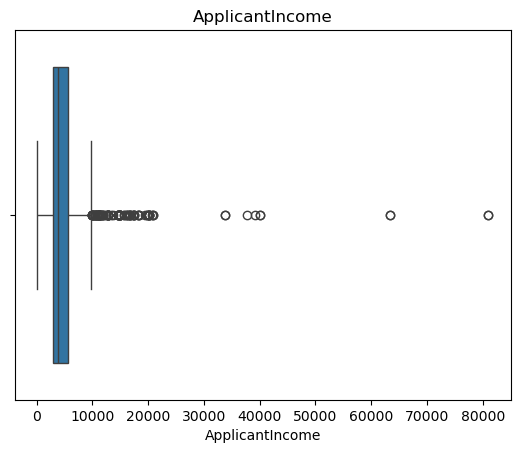

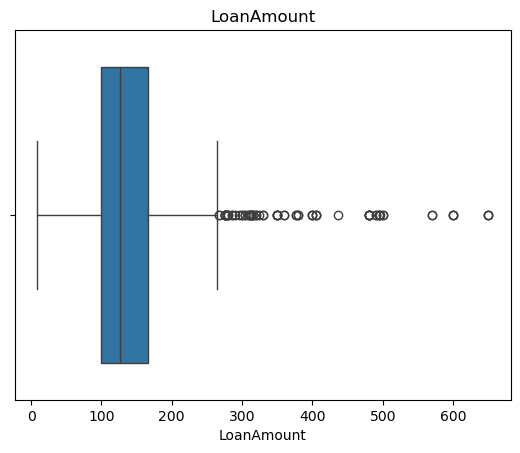

In [16]:
# Check for outliers using box plot under numerical cols
numerical_cols = loan_df.select_dtypes('float64')

# Plot the box plot
for x in numerical_cols:
    # Orient the plot in a specific way -- h for horizontal and v for vertical
    plt.figure()
    sns.boxplot(loan_df[x],orient='h')
    plt.title(x)

In [17]:
from scipy.stats.mstats import winsorize
# We're selecting only numerical cols
num_cols = numerical_cols.columns

# Replacing outlier values
for col in num_cols:
    loan_df[col] = winsorize(loan_df[col], limits=[0.1, 0.1])

#### Encoding

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Select the categorical cols
cat_cols = loan_df.select_dtypes('object').columns

for col in cat_cols:
    loan_df[col] = le.fit_transform(loan_df[col])

# Display the first 10 rows
loan_df.head(10)

,Gender,Married,ApplicantIncome,LoanAmount,Loan_Status
0,1,0,3750.0,176.0,0
1,0,1,3167.0,154.0,1
2,1,0,7333.0,120.0,0
3,1,1,3539.0,70.0,0
4,1,1,4708.0,150.0,1
5,1,0,3062.0,111.0,0
6,0,1,2423.0,130.0,1
7,1,1,5250.0,94.0,0
8,1,1,5167.0,200.0,1
9,0,1,2645.0,120.0,0


#### Scaling

In [19]:
# Figure out why scaling requires two nested square brackets
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
cols = ['ApplicantIncome','LoanAmount']

for col in cols:
    loan_df[col] = ss.fit_transform(loan_df[[col]])

loan_df

,Gender,Married,ApplicantIncome,LoanAmount,Loan_Status
0,1,0,-0.388557,0.813658,0
1,0,1,-0.653595,0.365893,1
2,1,0,1.240312,-0.326109,0
3,1,1,-0.484480,-1.343759,0
4,1,1,0.046960,0.284481,1
...,...,...,...,...,...
9782,1,1,-0.642912,-0.265050,0
9891,1,1,-0.911359,-0.438051,0
9983,1,0,-0.319456,-0.549992,1
9990,1,0,-1.026830,-0.081873,1


## Data preprocessing

In [20]:
# Check class balance
# normalize returns proportions of each value
loan_df['Loan_Status'].value_counts(normalize=True)

Loan_Status
1    0.676044
0    0.323956
Name: proportion, dtype: float64

## Data splitting

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
# Seperate inputs and output
y = loan_df['Loan_Status']
X = loan_df.drop('Loan_Status', axis=1)

### Class imbalance

#### A

In [23]:
# from imblearn.over_sampling import RandomOverSampler

In [24]:
# ros = RandomOverSampler(sampling_strategy=0.65)
# X_new, y_new = ros.fit_resample(X, y)

In [25]:
# y_new.value_counts(normalize=True)

#### B

In [26]:
from imblearn.under_sampling import RandomUnderSampler

In [27]:
# 0.75 seems to be the best proportion
rus = RandomUnderSampler(sampling_strategy=0.75)
X_new, y_new = rus.fit_resample(X, y)

In [28]:
y_new.value_counts()

Loan_Status
1    506
0    380
Name: count, dtype: int64

In [29]:
y_new.value_counts(normalize=True)

Loan_Status
1    0.571106
0    0.428894
Name: proportion, dtype: float64

### Splitting

In [30]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.3, stratify=y_new)

In [31]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(620, 4) (620,) (266, 4) (266,)


## Model building

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
logr_model = LogisticRegression()
logr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Evaluation

### Testing

In [34]:
y_pred = logr_model.predict(X_test)
y_pred

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 1])

### Evaluate

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

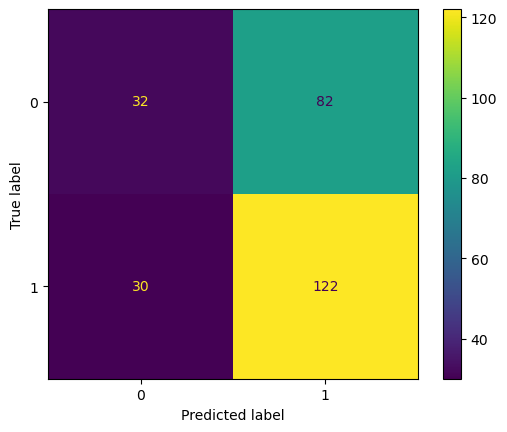

In [36]:
cmx = confusion_matrix(y_test,y_pred)

matrix = ConfusionMatrixDisplay(cmx, display_labels=logr_model.classes_)
matrix.plot()

In [37]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.5789473684210527

In [38]:
precision = precision_score(y_test, y_pred)
precision

0.5980392156862745

In [39]:
recall = recall_score(y_test, y_pred)
recall

0.8026315789473685

In [40]:
f1 = f1_score(y_test, y_pred)
f1

0.6853932584269663

# Linear Regression 

## Importation

In [41]:
# All necessary modules have been imported

In [42]:
df = pd.read_csv("electric_vehicles_spec_2025.csv")
df

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,Zeekr,7X Premium RWD,210,71.0,Lithium-ion,NaN,440.0,148,365,6.0,...,2000.0,539,5,RWD,JD - Large,4787,1930,1650,SUV,https://ev-database.org/car/3081/Zeekr-7X-Prem...
474,Zeekr,X Core RWD (MY25),190,49.0,Lithium-ion,NaN,343.0,148,265,5.9,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3197/Zeekr-X-Core-RWD
475,Zeekr,X Long Range RWD (MY25),190,65.0,Lithium-ion,NaN,343.0,146,360,5.6,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3198/Zeekr-X-Long-...
476,Zeekr,X Privilege AWD (MY25),190,65.0,Lithium-ion,NaN,543.0,153,350,3.8,...,1600.0,362,5,AWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3199/Zeekr-X-Privi...


## Data cleaning

### Dirt #1 - Missing values

In [43]:
df.isna().sum()

brand                          0
model                          1
top_speed_kmh                  0
battery_capacity_kWh           0
battery_type                   0
number_of_cells              202
torque_nm                      7
efficiency_wh_per_km           0
range_km                       0
acceleration_0_100_s           0
fast_charging_power_kw_dc      1
fast_charge_port               1
towing_capacity_kg            26
cargo_volume_l                 1
seats                          0
drivetrain                     0
segment                        0
length_mm                      0
width_mm                       0
height_mm                      0
car_body_type                  0
source_url                     0
dtype: int64

In [44]:
# Check the cols within each row to see if that row has a missing value
# It returns a Series
missing_rows = df.isnull().any(axis=1)

# Boolean indexing to print out such rows
df[missing_rows]

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5
5,Aiways,U6,160,60.0,Lithium-ion,NaN,315.0,150,350,7.0,...,NaN,472,5,FWD,JC - Medium,4805,1880,1641,SUV,https://ev-database.org/car/1766/Aiways-U6
38,BMW,i4 M50,225,81.3,Lithium-ion,NaN,795.0,197,450,3.9,...,1600.0,470,5,AWD,D - Large,4783,1852,1448,Liftback Sedan,https://ev-database.org/car/2201/BMW-i4-M50
39,BMW,i4 eDrive35,190,67.1,Lithium-ion,NaN,400.0,174,430,6.0,...,1600.0,470,5,RWD,D - Large,4783,1852,1448,Liftback Sedan,https://ev-database.org/car/2198/BMW-i4-eDrive35
40,BMW,i4 eDrive40,190,81.3,Lithium-ion,NaN,430.0,174,515,5.6,...,1600.0,470,5,RWD,D - Large,4783,1852,1448,Liftback Sedan,https://ev-database.org/car/2199/BMW-i4-eDrive40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,Zeekr,7X Premium RWD,210,71.0,Lithium-ion,NaN,440.0,148,365,6.0,...,2000.0,539,5,RWD,JD - Large,4787,1930,1650,SUV,https://ev-database.org/car/3081/Zeekr-7X-Prem...
474,Zeekr,X Core RWD (MY25),190,49.0,Lithium-ion,NaN,343.0,148,265,5.9,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3197/Zeekr-X-Core-RWD
475,Zeekr,X Long Range RWD (MY25),190,65.0,Lithium-ion,NaN,343.0,146,360,5.6,...,1600.0,362,5,RWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3198/Zeekr-X-Long-...
476,Zeekr,X Privilege AWD (MY25),190,65.0,Lithium-ion,NaN,543.0,153,350,3.8,...,1600.0,362,5,AWD,JB - Compact,4432,1836,1566,SUV,https://ev-database.org/car/3199/Zeekr-X-Privi...


In [45]:
## For torque, -- 7
# There are no records of their biodata on the electric vehicle records
# Thus, droping is the best option
df.dropna(subset='torque_nm',inplace=True)

In [46]:
## For towing capacity, -- 26
df.dropna(subset=['towing_capacity_kg'],inplace=True)

In [47]:
### For num. of cells, -- 202
## By going through the data source, the actual values can't be obtained
df.dropna(subset=['number_of_cells'],inplace=True)

In [48]:
### For model, -- 1
## By going through the data source, the actual value can be obtained and is thus replaced
df.loc[477,'model'] = 'firefly'

In [49]:
### For fast charging power, -- 1
# Different options are available to different countries, thus we settle for the more common actual value
df.loc[356,'fast_charging_power_kw_dc'] = 2.3
df.loc[356,'fast_charge_port'] = 'Wall Plug'

In [50]:
### For cargo volume, -- 1
## 1. No data is available on it 
## 2. We can't replace with mean, median or mode
## 3. Best option is to drop
df.dropna(subset=['cargo_volume_l'], inplace=True)

### Dirt #2 - Duplicates

In [51]:
df.isna().sum()

brand                        0
model                        0
top_speed_kmh                0
battery_capacity_kWh         0
battery_type                 0
number_of_cells              0
torque_nm                    0
efficiency_wh_per_km         0
range_km                     0
acceleration_0_100_s         0
fast_charging_power_kw_dc    0
fast_charge_port             0
towing_capacity_kg           0
cargo_volume_l               0
seats                        0
drivetrain                   0
segment                      0
length_mm                    0
width_mm                     0
height_mm                    0
car_body_type                0
source_url                   0
dtype: int64

In [52]:
df.duplicated().sum()

np.int64(0)

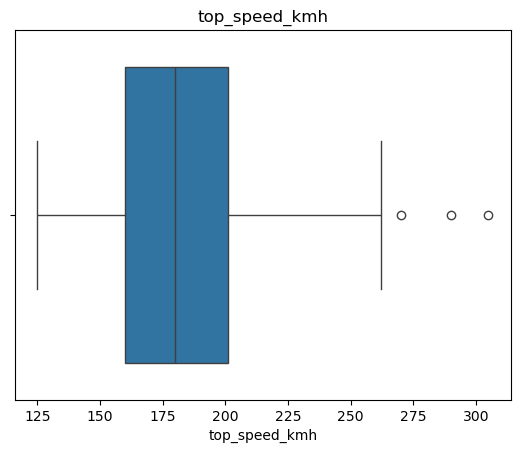

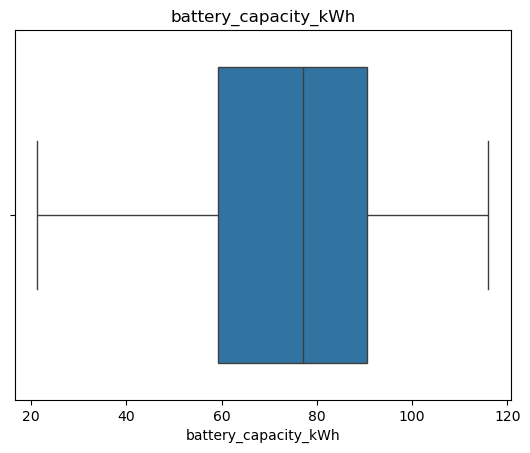

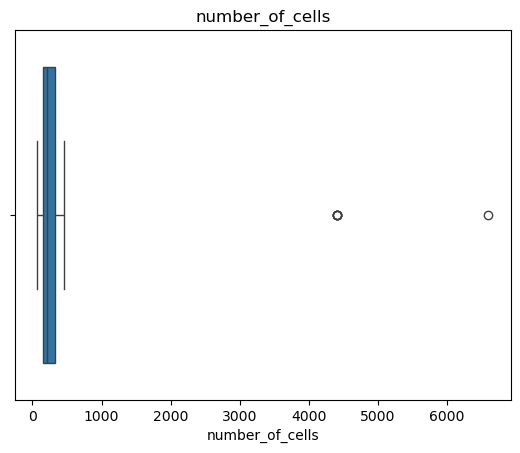

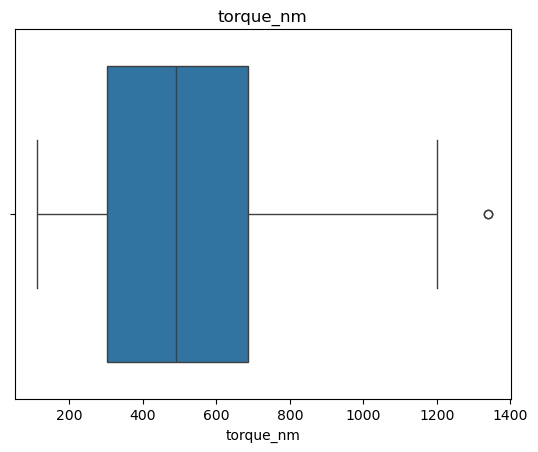

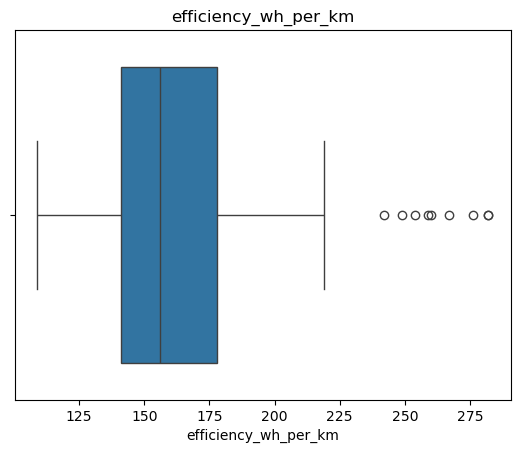

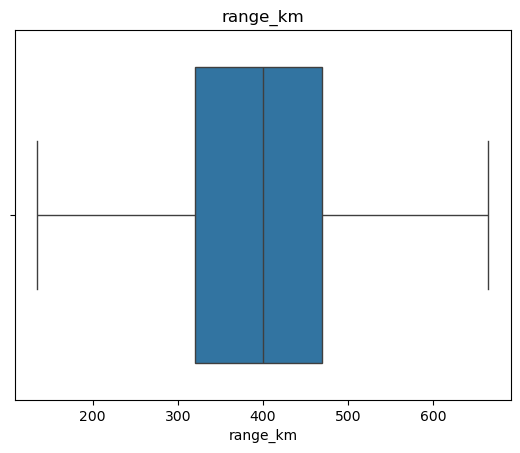

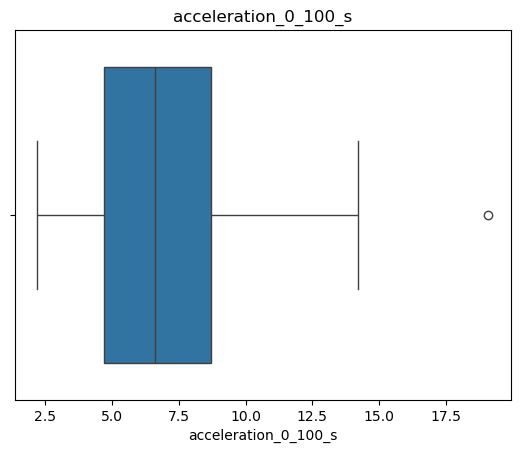

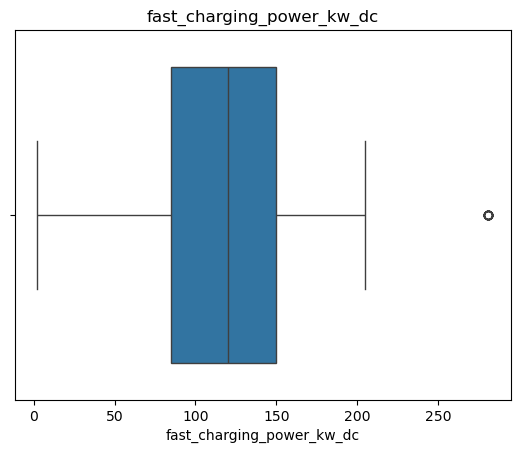

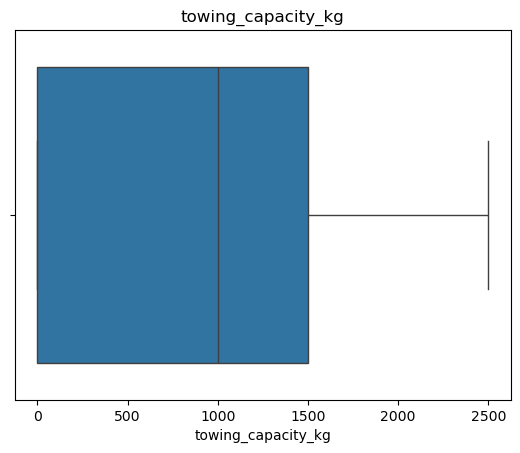

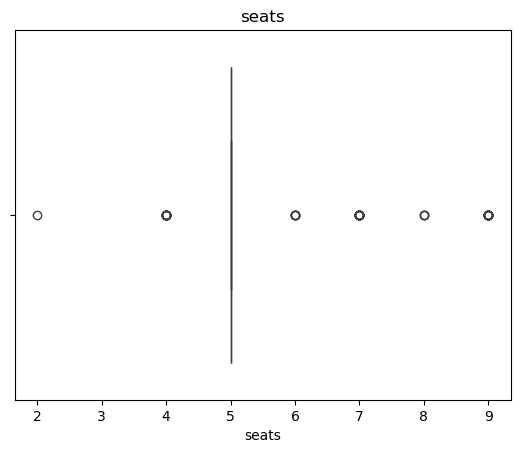

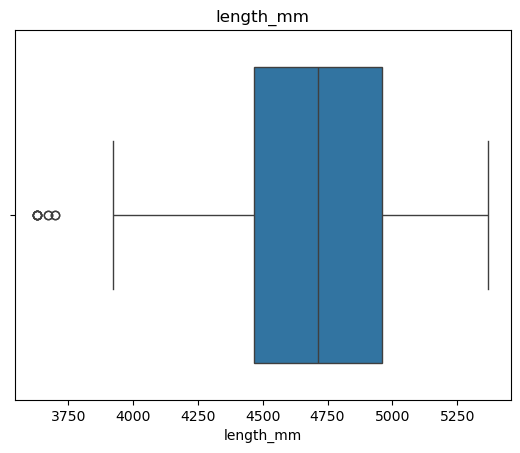

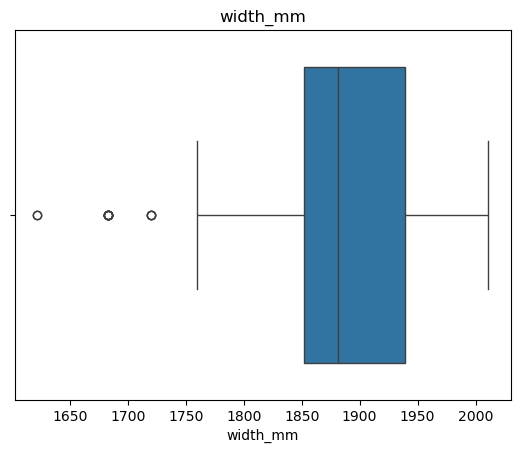

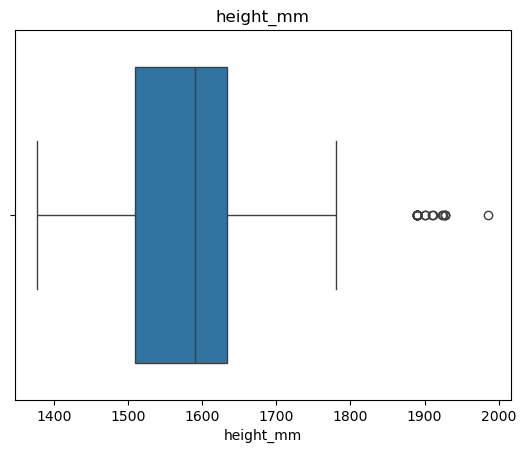

In [53]:
# Check for outliers using box plot under numerical cols
numerical_cols = df.select_dtypes('number')

# Plot the box plot
for x in numerical_cols:
    # Orient the plot in a specific way -- h for horizontal and v for vertical
    plt.figure()
    sns.boxplot(df[x],orient='h')
    plt.title(x)

In [54]:
from scipy.stats.mstats import winsorize
# We're selecting only numerical cols with innegligible outliers
num_cols = ['fast_charging_power_kw_dc','height_mm']

# Replacing outlier values
for col in num_cols:
    df[col] = winsorize(df[col], limits=[0.05, 0.05])

### Encoding

In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Select the categorical cols
cat_cols = df.select_dtypes('object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Display the first 10 rows
df.head(10)

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,0,24,155,37.8,0,192.0,235.0,156,225,7.0,...,0.0,6,4,1,1,3673,1683,1518,1,47
1,0,25,155,37.8,0,192.0,235.0,149,225,7.0,...,0.0,6,4,1,1,3673,1683,1518,1,46
2,0,29,200,50.8,0,102.0,345.0,158,280,5.9,...,0.0,21,5,1,6,4187,1779,1557,3,221
3,0,30,200,50.8,0,102.0,345.0,158,280,6.2,...,0.0,21,5,1,6,4187,1779,1557,3,220
6,1,194,150,50.8,0,102.0,260.0,128,320,9.0,...,0.0,28,5,1,6,4173,1781,1532,3,141
7,1,195,200,50.8,0,102.0,345.0,164,310,6.0,...,0.0,28,5,1,6,4173,1781,1505,3,142
8,2,31,160,52.0,0,184.0,285.0,138,310,7.4,...,500.0,13,5,1,1,3997,1823,1512,1,186
9,2,32,170,52.0,0,184.0,300.0,144,305,6.4,...,500.0,13,5,1,1,3997,1823,1512,1,187
10,3,33,210,75.8,0,150.0,435.0,146,465,6.0,...,2100.0,51,5,2,9,4928,1923,1455,6,219
11,3,34,210,94.9,0,180.0,565.0,151,575,5.4,...,2100.0,51,5,2,9,4928,1923,1455,6,190


### Scaling

In [56]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
cols = df.select_dtypes('number').columns.drop('range_km')

for col in cols:
    df[col] = ss.fit_transform(df[[col]])

df

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,-1.786863,-1.412999,-0.840439,-1.835664,0.0,-0.216954,-1.123424,-0.176963,225,0.012874,...,-1.267074,-1.514970,-1.182552,0.188064,-1.707964,-2.664168,-2.680583,-0.588913,-1.552793,-1.113469
1,-1.786863,-1.399976,-0.840439,-1.835664,0.0,-0.216954,-1.123424,-0.400508,225,0.012874,...,-1.267074,-1.514970,-1.182552,0.188064,-1.707964,-2.664168,-2.680583,-0.588913,-1.552793,-1.126492
2,-1.786863,-1.347884,0.468101,-1.165734,0.0,-0.346831,-0.683632,-0.113093,280,-0.367638,...,-1.267074,-0.902907,-0.293968,0.188064,-0.048656,-1.276442,-1.407045,-0.294357,-0.103520,1.152538
3,-1.786863,-1.334861,0.468101,-1.165734,0.0,-0.346831,-0.683632,-0.113093,280,-0.263862,...,-1.267074,-0.902907,-0.293968,0.188064,-0.048656,-1.276442,-1.407045,-0.294357,-0.103520,1.139515
6,-1.690687,0.800916,-0.985832,-1.165734,0.0,-0.346831,-1.023471,-1.071143,320,0.704716,...,-1.267074,-0.617278,-0.293968,0.188064,-0.048656,-1.314240,-1.380513,-0.483175,-0.103520,0.110696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,1.386970,-0.397202,-0.113472,1.730428,0.0,-0.199637,1.575301,0.844957,455,-0.713559,...,1.673172,-1.310949,1.483201,-1.032056,1.278790,1.018434,1.047167,1.118001,-0.103520,-1.347884
468,1.483147,-1.725552,0.468101,1.060498,0.0,-0.335286,-0.691628,-0.304703,505,0.082059,...,0.737639,0.892476,-0.293968,1.408183,-0.712379,0.797046,1.511478,-0.271699,-0.828157,-1.022308
469,1.483147,-1.712529,0.468101,1.060498,0.0,-0.335286,0.679724,-0.081158,480,-1.094072,...,1.405877,0.892476,-0.293968,-1.032056,-0.712379,0.797046,1.511478,-0.271699,-0.828157,-1.009285
470,1.483147,-1.699505,0.468101,1.060498,0.0,-0.335286,0.679724,0.014647,480,-1.094072,...,1.405877,0.892476,-0.293968,-1.032056,-0.712379,0.797046,1.511478,-0.362332,-0.828157,-0.996262


## Data splitting

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
# y always rep. your target variable
y = df['range_km']
# X reps the input features for your model
X = df.drop(axis=1,columns='range_km')

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=40)

In [59]:
# Ensuring the splitting is done correctly
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(199, 21) (199,) (67, 21) (67,)


## Model building

### Initial build

In [60]:
# Import linear regression
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Feature selection

In [61]:
from sklearn.feature_selection import RFE

# Recursive feature elimination
# Select best 5 except if model performance is low then use more
selector = RFE(estimator=model, n_features_to_select=5)

selector = selector.fit(X, y)

selected_features = X.columns[selector.support_]
print(selected_features)

X_train_new = X_train[selected_features]
X_test_new = X_test[selected_features]

print(X_train_new.shape, X_test_new.shape)

Index(['battery_capacity_kWh', 'efficiency_wh_per_km', 'acceleration_0_100_s',
       'length_mm', 'height_mm'],
      dtype='object')
(199, 5) (67, 5)


### Final build

In [62]:
# Fit again with RFE Feature
model.fit(X_train_new, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Evaluation 

### Test 

In [63]:
# Evaluation using test
y_pred = model.predict(X_test_new)
y_pred

array([523.89445137, 287.93400276, 437.97715027, 470.3462534 ,
       319.14003738, 458.58349129, 503.98926663, 526.19949679,
       275.05378588, 287.76950653, 547.32338844, 369.10060147,
       309.43901486, 487.08475648, 399.39667635, 228.89758235,
       410.35732125, 377.4030413 , 422.45914369, 519.29506929,
       416.52299683, 437.13487782, 512.83193569, 188.72289616,
       304.03773541, 302.05443975, 424.43042854, 513.51628981,
       281.2619386 , 287.93400276, 431.49990451, 543.17346439,
       459.96852491, 190.00981506, 489.90732655, 168.06468328,
       413.67358192, 182.18512027, 453.33926628, 361.81410054,
       419.93117321, 421.77874201, 423.96174661, 343.27517305,
       301.88994352, 542.79937069, 452.44203419, 198.65463965,
       518.56541181, 334.9331934 , 416.48644212, 545.31114542,
       416.44710935, 396.97134526, 434.428829  , 302.05443975,
       502.87003225, 399.73178733, 346.07804661, 276.10560843,
       529.92473422, 487.96407363, 395.01058481, 342.30

### Metrics

In [64]:
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

In [65]:
r2 = r2_score(y_test, y_pred)
r2

0.9460582452016546

In [66]:
mse = mean_squared_error(y_test, y_pred)
mse

620.8522940695859

In [67]:
rmse = root_mean_squared_error(y_test, y_pred)
rmse

24.91690779510142

In [68]:
# Check the rule of thumb
# Rule of thumb
# 20% of Max y value
print(rmse < 0.2 * max(y))

True
